Import libraries

In [1]:
import sys
sys.path.append("src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             confusion_matrix, classification_report)

from data_utils import load_data, preprocess

print("Libraries loaded!")

Libraries loaded!


In [2]:
train_df, valid_df, test_df = load_data(
    "data/liar_dataset/train.tsv",
    "data/liar_dataset/valid.tsv",
    "data/liar_dataset/test.tsv"
)

train_df = preprocess(train_df)
valid_df = preprocess(valid_df)
test_df  = preprocess(test_df)

X_train = train_df["clean_statement"]
y_train = train_df["binary_label"]

X_valid = valid_df["clean_statement"]
y_valid = valid_df["binary_label"]

X_test  = test_df["clean_statement"]
y_test  = test_df["binary_label"]

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test :", X_test.shape)

Train: (10240,)
Valid: (1284,)
Test : (1267,)


In [3]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF matrix shape:", X_train_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

TF-IDF matrix shape: (10240, 10000)
Vocabulary size: 10000


In [4]:
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

lr_preds = lr_model.predict(X_valid_tfidf)

print("=" * 40)
print("Logistic Regression Results")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_valid, lr_preds):.4f}")
print(f"F1 Score  : {f1_score(y_valid, lr_preds, pos_label='fake'):.4f}")
print(f"Precision : {precision_score(y_valid, lr_preds, pos_label='fake'):.4f}")
print(f"Recall    : {recall_score(y_valid, lr_preds, pos_label='fake'):.4f}")
print("\nClassification Report:")
print(classification_report(y_valid, lr_preds))

Logistic Regression Results
Accuracy  : 0.6153
F1 Score  : 0.5426
Precision : 0.6315
Recall    : 0.4756

Classification Report:
              precision    recall  f1-score   support

        fake       0.63      0.48      0.54       616
        real       0.61      0.74      0.67       668

    accuracy                           0.62      1284
   macro avg       0.62      0.61      0.61      1284
weighted avg       0.62      0.62      0.61      1284



In [5]:
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

nb_preds = nb_model.predict(X_valid_tfidf)

print("=" * 40)
print("Naive Bayes Results")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_valid, nb_preds):.4f}")
print(f"F1 Score  : {f1_score(y_valid, nb_preds, pos_label='fake'):.4f}")
print(f"Precision : {precision_score(y_valid, nb_preds, pos_label='fake'):.4f}")
print(f"Recall    : {recall_score(y_valid, nb_preds, pos_label='fake'):.4f}")

Naive Bayes Results
Accuracy  : 0.5966
F1 Score  : 0.5358
Precision : 0.5980
Recall    : 0.4854


In [6]:
svm_model = LinearSVC(max_iter=2000, C=1.0, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

svm_preds = svm_model.predict(X_valid_tfidf)

print("=" * 40)
print("SVM Results")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_valid, svm_preds):.4f}")
print(f"F1 Score  : {f1_score(y_valid, svm_preds, pos_label='fake'):.4f}")
print(f"Precision : {precision_score(y_valid, svm_preds, pos_label='fake'):.4f}")
print(f"Recall    : {recall_score(y_valid, svm_preds, pos_label='fake'):.4f}")

SVM Results
Accuracy  : 0.5997
F1 Score  : 0.5651
Precision : 0.5901
Recall    : 0.5422


              Model  Accuracy  F1 Score
Logistic Regression  0.615265  0.542593
        Naive Bayes  0.596573  0.535842
                SVM  0.599688  0.565144


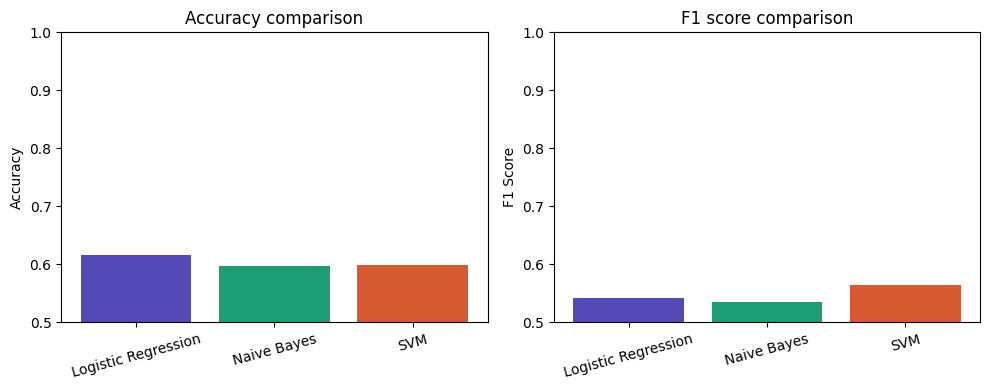

In [7]:
results = {
    "Model": ["Logistic Regression", "Naive Bayes", "SVM"],
    "Accuracy": [
        accuracy_score(y_valid, lr_preds),
        accuracy_score(y_valid, nb_preds),
        accuracy_score(y_valid, svm_preds)
    ],
    "F1 Score": [
        f1_score(y_valid, lr_preds, pos_label='fake'),
        f1_score(y_valid, nb_preds, pos_label='fake'),
        f1_score(y_valid, svm_preds, pos_label='fake')
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(results_df["Model"], results_df["Accuracy"],
            color=["#534AB7", "#1D9E75", "#D85A30"])
axes[0].set_title("Accuracy comparison")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.5, 1.0)
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(results_df["Model"], results_df["F1 Score"],
            color=["#534AB7", "#1D9E75", "#D85A30"])
axes[1].set_title("F1 score comparison")
axes[1].set_ylabel("F1 Score")
axes[1].set_ylim(0.5, 1.0)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

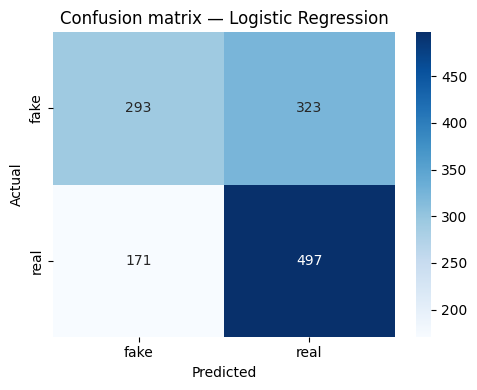

In [8]:
# Plot confusion matrix for Logistic Regression
cm = confusion_matrix(y_valid, lr_preds, labels=["fake", "real"])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["fake", "real"],
            yticklabels=["fake", "real"],
            cmap="Blues")
plt.title("Confusion matrix — Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [9]:
import os
os.makedirs("models", exist_ok=True)

# Save model and vectorizer
joblib.dump(lr_model, "models/baseline_model.pkl")
joblib.dump(tfidf,    "models/tfidf_vectorizer.pkl")

print("Models saved!")
print("models/baseline_model.pkl")
print("models/tfidf_vectorizer.pkl")

Models saved!
models/baseline_model.pkl
models/tfidf_vectorizer.pkl


In [10]:
from predict import predict

test_headlines = [
    "The government is hiding the truth about vaccines",
    "Senate passes new healthcare bill with bipartisan support",
    "Scientists discover cure for all diseases overnight",
    "President signs executive order on climate change"
]

print("=" * 50)
for headline in test_headlines:
    pred, conf = predict(headline)
    print(f"Headline : {headline[:50]}...")
    print(f"Prediction: {pred.upper()} ({conf:.2%} confidence)")
    print("-" * 50)

Headline : The government is hiding the truth about vaccines...
Prediction: FAKE (70.96% confidence)
--------------------------------------------------
Headline : Senate passes new healthcare bill with bipartisan ...
Prediction: REAL (58.64% confidence)
--------------------------------------------------
Headline : Scientists discover cure for all diseases overnigh...
Prediction: FAKE (57.24% confidence)
--------------------------------------------------
Headline : President signs executive order on climate change...
Prediction: FAKE (53.43% confidence)
--------------------------------------------------


  Hyperparameter Tuning + Error Analysis

In [11]:
import sys
sys.path.append("src")

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from data_utils import load_data, preprocess

# Load data
train_df, valid_df, test_df = load_data(
    "data/liar_dataset/train.tsv",
    "data/liar_dataset/valid.tsv",
    "data/liar_dataset/test.tsv"
)

train_df = preprocess(train_df)
valid_df = preprocess(valid_df)
test_df  = preprocess(test_df)

X_train = train_df["clean_statement"]
y_train = train_df["binary_label"]
X_valid = valid_df["clean_statement"]
y_valid = valid_df["binary_label"]

# Load saved vectorizer and model
tfidf    = joblib.load("models/tfidf_vectorizer.pkl")
lr_model = joblib.load("models/baseline_model.pkl")

X_train_tfidf = tfidf.transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)

print("Data and models loaded!")

Data and models loaded!


In [12]:
from sklearn.svm import LinearSVC

configs = [
    {"max_features": 5000,  "ngram_range": (1,1)},
    {"max_features": 10000, "ngram_range": (1,2)},
    {"max_features": 20000, "ngram_range": (1,2)},
    {"max_features": 10000, "ngram_range": (1,3)},
]

print(f"{'Config':<40} {'Accuracy':>10} {'F1':>10}")
print("-" * 62)

for cfg in configs:
    vec = TfidfVectorizer(**cfg, min_df=2, max_df=0.95)
    X_tr = vec.fit_transform(X_train)
    X_vl = vec.transform(X_valid)

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr, y_train)
    preds = model.predict(X_vl)

    acc = accuracy_score(y_valid, preds)
    f1  = f1_score(y_valid, preds, pos_label='fake')
    label = f"features={cfg['max_features']} ngram={cfg['ngram_range']}"
    print(f"{label:<40} {acc:>10.4f} {f1:>10.4f}")

Config                                     Accuracy         F1
--------------------------------------------------------------
features=5000 ngram=(1, 1)                   0.6090     0.5394
features=10000 ngram=(1, 2)                  0.6153     0.5426
features=20000 ngram=(1, 2)                  0.6114     0.5341
features=10000 ngram=(1, 3)                  0.6160     0.5422


In [13]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=2, max_df=0.95)),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range' : [(1,1), (1,2)],
    'clf__C'             : [0.1, 1.0, 10.0]
}

print("Running GridSearchCV — this takes 2-3 minutes...")

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest parameters:", grid_search.best_params_)
print("Best CV score  :", f"{grid_search.best_score_:.4f}")

best_preds = grid_search.predict(X_valid)
print(f"Validation Accuracy: {accuracy_score(y_valid, best_preds):.4f}")
print(f"Validation F1      : {f1_score(y_valid, best_preds, pos_label='fake'):.4f}")

Running GridSearchCV — this takes 2-3 minutes...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters: {'clf__C': 1.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best CV score  : 0.5835
Validation Accuracy: 0.6153
Validation F1      : 0.5426


In [14]:
import re

def extract_features(df):
    df = df.copy()
    df["exclamation_count"] = df["statement"].apply(
        lambda x: str(x).count('!'))
    df["question_count"] = df["statement"].apply(
        lambda x: str(x).count('?'))
    df["caps_ratio"] = df["statement"].apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1))
    df["word_count"] = df["clean_statement"].apply(
        lambda x: len(str(x).split()))
    return df

train_feat = extract_features(train_df)
valid_feat = extract_features(valid_df)

extra_cols = ["exclamation_count", "question_count",
              "caps_ratio", "word_count"]

from scipy.sparse import hstack
import numpy as np

X_train_extra = hstack([
    X_train_tfidf,
    train_feat[extra_cols].values
])
X_valid_extra = hstack([
    X_valid_tfidf,
    valid_feat[extra_cols].values
])

lr_extra = LogisticRegression(max_iter=1000, random_state=42)
lr_extra.fit(X_train_extra, y_train)
extra_preds = lr_extra.predict(X_valid_extra)

print("=" * 40)
print("LR + Extra Features Results")
print("=" * 40)
print(f"Accuracy : {accuracy_score(y_valid, extra_preds):.4f}")
print(f"F1 Score : {f1_score(y_valid, extra_preds, pos_label='fake'):.4f}")

LR + Extra Features Results
Accuracy : 0.6215
F1 Score : 0.5525


In [15]:
valid_df["prediction"] = best_preds
valid_df["correct"]    = valid_df["prediction"] == valid_df["binary_label"]

# Wrong predictions only
errors = valid_df[valid_df["correct"] == False]

print(f"Total errors: {len(errors)} out of {len(valid_df)}")
print(f"Error rate  : {len(errors)/len(valid_df):.2%}\n")

# False positives — predicted fake but actually real
fp = valid_df[
    (valid_df["prediction"] == "fake") &
    (valid_df["binary_label"] == "real")
]
print(f"False Positives (predicted fake, actually real): {len(fp)}")
print(fp["statement"].head(3).to_string())

print()

# False negatives — predicted real but actually fake
fn = valid_df[
    (valid_df["prediction"] == "real") &
    (valid_df["binary_label"] == "fake")
]
print(f"\nFalse Negatives (predicted real, actually fake): {len(fn)}")
print(fn["statement"].head(3).to_string())

Total errors: 494 out of 1284
Error rate  : 38.47%

False Positives (predicted fake, actually real): 171
9     Bill White has a long history of trying to lim...
15    Rick Perry has advocated abandoning Social Sec...
26    We are poised to get rid of over 1,000 more re...


False Negatives (predicted real, actually fake): 323
0     We have less Americans working now than in the...
5     Says when armed civilians stop mass shootings ...
14    Every citizen is entitled to the freedom of sp...


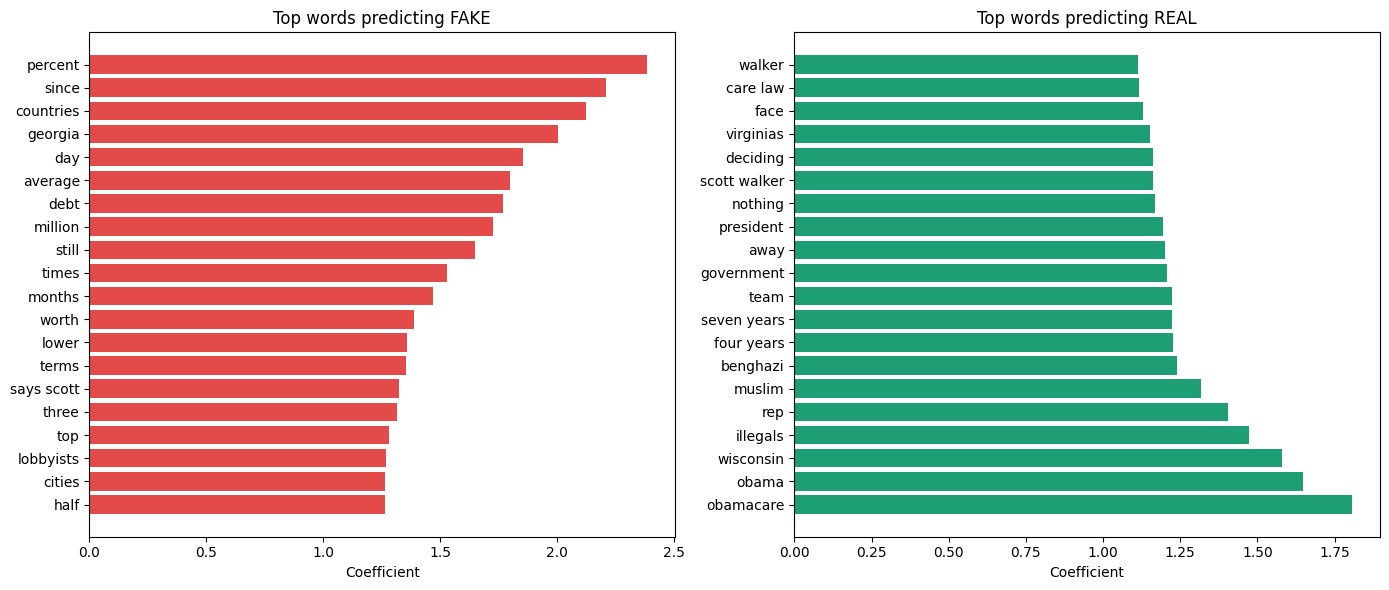

In [16]:
# Get feature names and coefficients
feature_names = tfidf.get_feature_names_out()
coefficients  = lr_model.coef_[0]

# Top words pushing toward FAKE
top_fake_idx  = np.argsort(coefficients)[-20:]
top_fake_words = [(feature_names[i], coefficients[i])
                  for i in top_fake_idx]

# Top words pushing toward REAL
top_real_idx  = np.argsort(coefficients)[:20]
top_real_words = [(feature_names[i], abs(coefficients[i]))
                  for i in top_real_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Fake words
words_f, scores_f = zip(*top_fake_words)
axes[0].barh(words_f, scores_f, color="#E24B4A")
axes[0].set_title("Top words predicting FAKE")
axes[0].set_xlabel("Coefficient")

# Real words
words_r, scores_r = zip(*top_real_words)
axes[1].barh(words_r, scores_r, color="#1D9E75")
axes[1].set_title("Top words predicting REAL")
axes[1].set_xlabel("Coefficient")

plt.tight_layout()
plt.show()

In [17]:
best_model = grid_search.best_estimator_

joblib.dump(best_model, "models/best_pipeline.pkl")
print("Best model saved to models/best_pipeline.pkl")

# Final test set evaluation
test_preds = best_model.predict(test_df["clean_statement"])
print("\nFinal Test Set Results:")
print(f"Accuracy : {accuracy_score(y_test, test_preds):.4f}")
print(f"F1 Score : {f1_score(y_test, test_preds, pos_label='fake'):.4f}")

Best model saved to models/best_pipeline.pkl

Final Test Set Results:
Accuracy : 0.6251
F1 Score : 0.5057
